In [117]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [118]:
df = pd.read_csv('../data/lab04/q03.csv')

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   index                     1000 non-null   int64 
 1   Patient Id                1000 non-null   object
 2   Age                       1000 non-null   int64 
 3   Gender                    1000 non-null   int64 
 4   Air Pollution             1000 non-null   int64 
 5   Alcohol use               1000 non-null   int64 
 6   Dust Allergy              1000 non-null   int64 
 7   OccuPational Hazards      1000 non-null   int64 
 8   Genetic Risk              1000 non-null   int64 
 9   chronic Lung Disease      1000 non-null   int64 
 10  Balanced Diet             1000 non-null   int64 
 11  Obesity                   1000 non-null   int64 
 12  Smoking                   1000 non-null   int64 
 13  Passive Smoker            1000 non-null   int64 
 14  Chest Pain               

,index,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,0,P1,33,1,2,4,5,4,3,2,...,3,4,2,2,3,1,2,3,4,Low
1,1,P10,17,1,3,1,5,3,4,2,...,1,3,7,8,6,2,1,7,2,Medium
2,2,P100,35,1,4,5,6,5,5,4,...,8,7,9,2,1,4,6,7,2,High
3,3,P1000,37,1,7,7,7,7,6,7,...,4,2,3,1,4,5,6,7,5,High
4,4,P101,46,1,6,8,7,7,7,6,...,3,2,4,1,4,2,4,2,3,High


In [119]:
df.drop(columns=['index', 'Patient Id'], inplace=True)

In [120]:
df.duplicated().sum() # no duplicates

np.int64(848)

In [121]:
encoding = {'Low': 0, 'Medium': 1, 'High': 2}
df['Level'] = df['Level'].map(encoding)

df.head()

,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,33,1,2,4,5,4,3,2,2,4,...,3,4,2,2,3,1,2,3,4,0
1,17,1,3,1,5,3,4,2,2,2,...,1,3,7,8,6,2,1,7,2,1
2,35,1,4,5,6,5,5,4,6,7,...,8,7,9,2,1,4,6,7,2,2
3,37,1,7,7,7,7,6,7,7,7,...,4,2,3,1,4,5,6,7,5,2
4,46,1,6,8,7,7,7,6,7,7,...,3,2,4,1,4,2,4,2,3,2


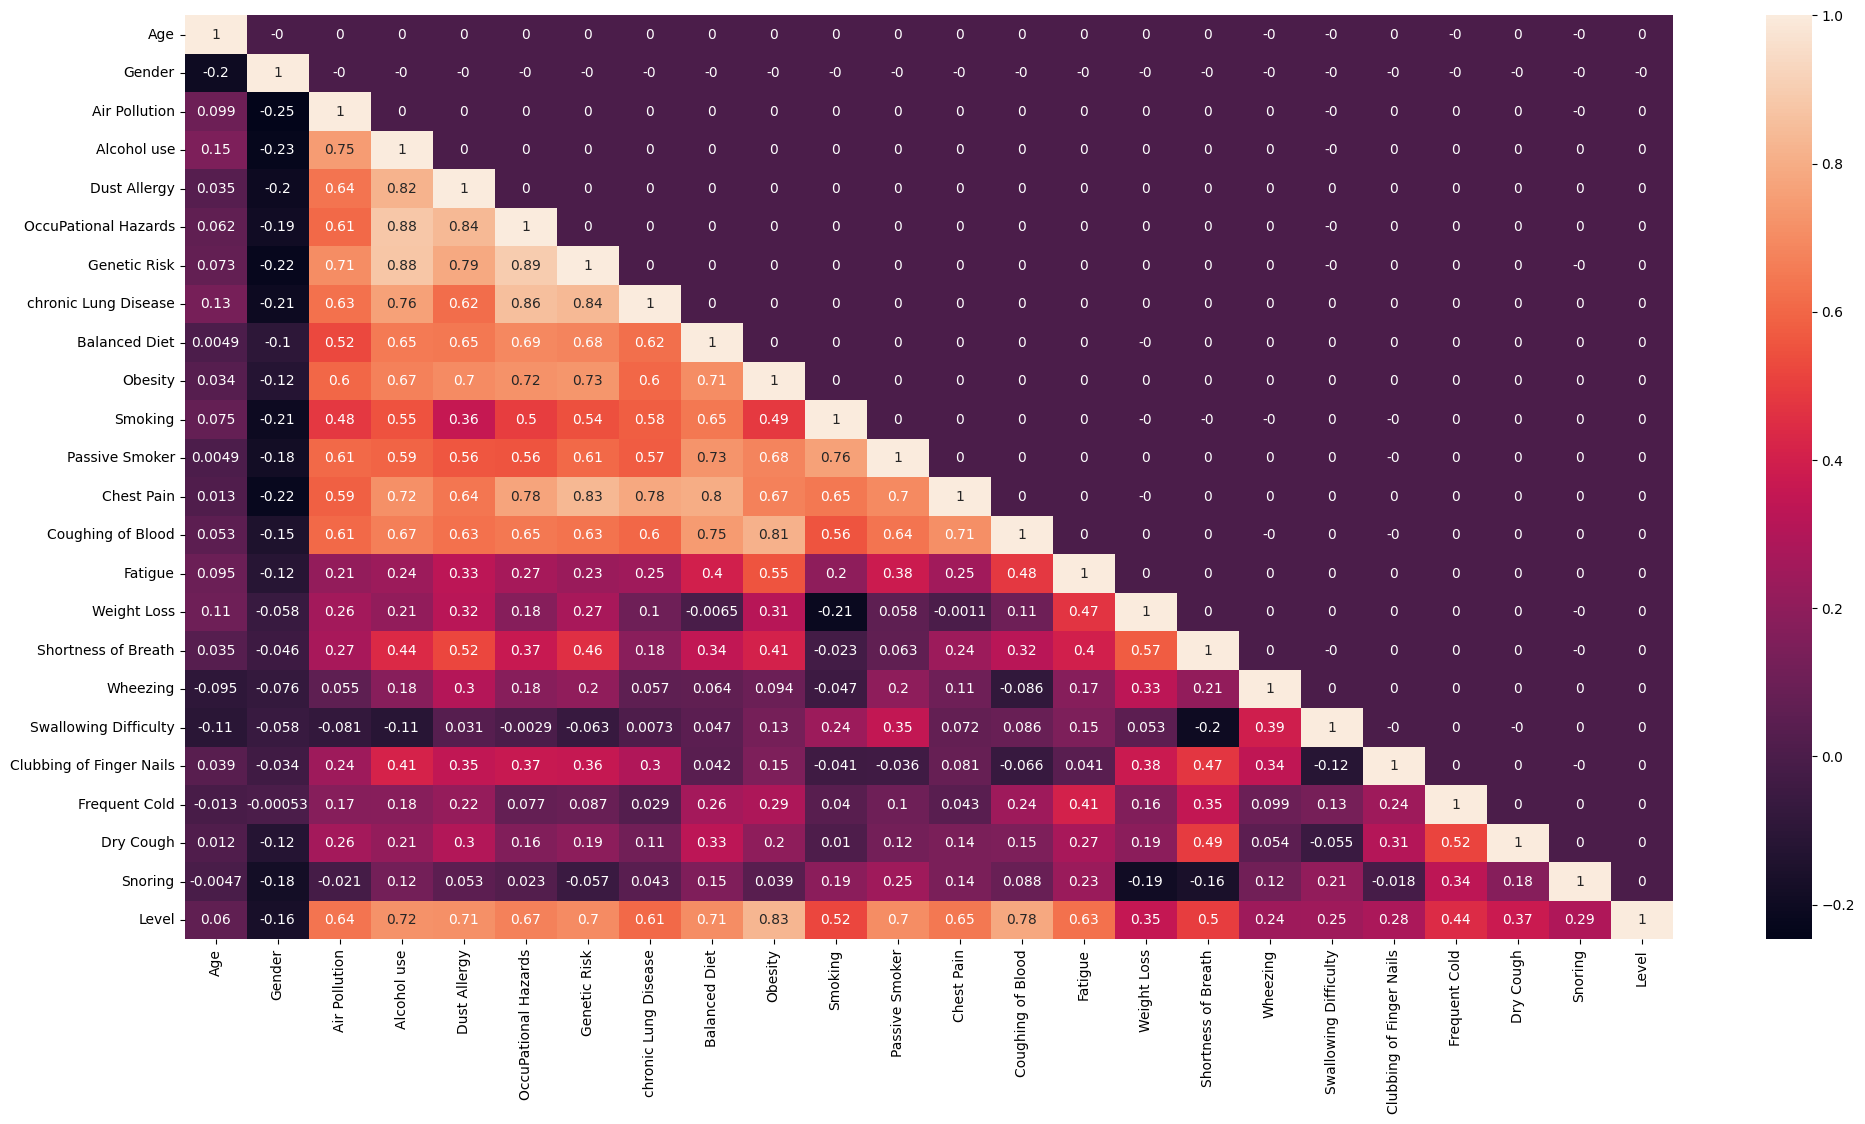

In [122]:
plt.figure(figsize=(24, 12))
corr = df.corr(numeric_only=True, method='pearson')
sns.heatmap(data=corr * np.tri(*corr.shape), annot=True)
plt.show()

In [123]:

df_alt = df[['Age', 'Gender', 'Smoking', 'Weight Loss', 'Shortness of Breath', 'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails', 'Frequent Cold', 'Dry Cough', 'Snoring', 'Level']]

df_alt

,Age,Gender,Smoking,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,33,1,3,4,2,2,3,1,2,3,4,0
1,17,1,2,3,7,8,6,2,1,7,2,1
2,35,1,2,7,9,2,1,4,6,7,2,2
3,37,1,7,2,3,1,4,5,6,7,5,2
4,46,1,8,2,4,1,4,2,4,2,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...
995,44,1,7,3,2,7,8,2,4,5,3,2
996,37,2,7,6,5,7,2,4,3,1,4,2
997,25,2,2,7,9,2,1,4,6,7,2,2
998,18,2,8,2,4,1,4,2,4,2,3,2


In [124]:
# decision trees need not scaled data as they don't require distance based calculations

In [125]:
X = df_alt.drop(columns=['Level'])
y = df_alt['Level']

# training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

dt = DecisionTreeClassifier(random_state=0)
dt.fit(X_train, y_train)

print(f"80-20 split score: {dt.score(X_test, y_test)}")

# validation
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.3, random_state=0)
dt.fit(X_train, y_train)

print(f"70-30 split-of-training score: {dt.score(X_test, y_test)}")

80-20 split score: 1.0
70-30 split-of-training score: 1.0
